In [3]:
# -*- coding: utf-8 -*-
"""
Created on Tue Jun 10 15:29:07 2025

@author: zou.yuheng
"""


#表格内容完整，没有进行数据清洗和数据预处理的需要
# 导入必要的库
import pandas as pd  # 用于数据处理和分析
import matplotlib.pyplot as plt  # 用于数据可视化
import seaborn as sns  # 用于数据可视化（基于matplotlib，提供更美观的样式）
from sklearn.model_selection import train_test_split  # 用于数据集划分
from sklearn.preprocessing import StandardScaler  # 用于特征标准化
from sklearn.linear_model import LinearRegression  # 用于线性回归模型
from sklearn.metrics import mean_squared_error, r2_score  # 用于模型评估指标
import statsmodels.api as sm  # 用于统计分析和时间序列分析
from statsmodels.tsa.arima.model import ARIMA  # 用于ARIMA时间序列模型
import warnings  # 用于警告处理

In [5]:
# 读取CSV文件
file_path = "supermarket_sales.csv"
supermarket_data = pd.read_csv(file_path)

# 显示数据前5行
print(supermarket_data.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  10:

In [6]:
# 数据分析与可视化部分

# 1. 销售趋势分析
# 将 'Date' 列转换为日期格式
supermarket_data['Date'] = pd.to_datetime(supermarket_data['Date'])

# 按日期统计每日销售额
daily_sales = supermarket_data.groupby('Date')['Total'].sum().reset_index()

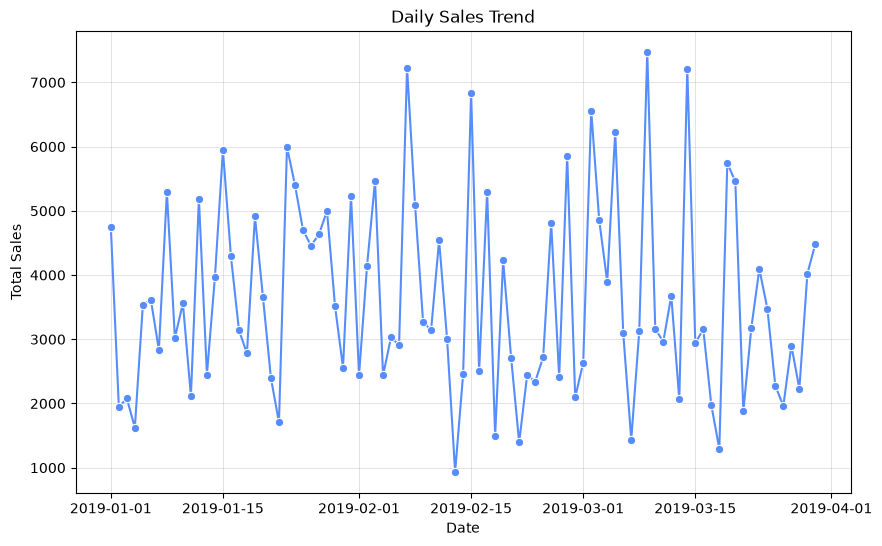

In [7]:
# 绘制每日销售趋势图
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Total', data=daily_sales, marker='o')
plt.title('Daily Sales Trend')  # 设置标题
plt.xlabel('Date')  # 设置x轴标签
plt.ylabel('Total Sales')  # 设置y轴标签
plt.grid(True)  # 添加网格
plt.show()

In [8]:
# 2. 客户类型分析
# 统计会员和普通客户的购买次数和销售额
customer_type_analysis = supermarket_data.groupby('Customer type').agg({
    'Invoice ID': 'count',  # 统计购买次数
    'Total': 'sum'  # 统计销售额
}).rename(columns={'Invoice ID': 'Purchase Count', 'Total': 'Total Sales'}).reset_index()

C:\Users\xingh\AppData\Local\Temp\ipykernel_14080\3038242374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer type', y='Total Sales', data=customer_type_analysis, palette='viridis')


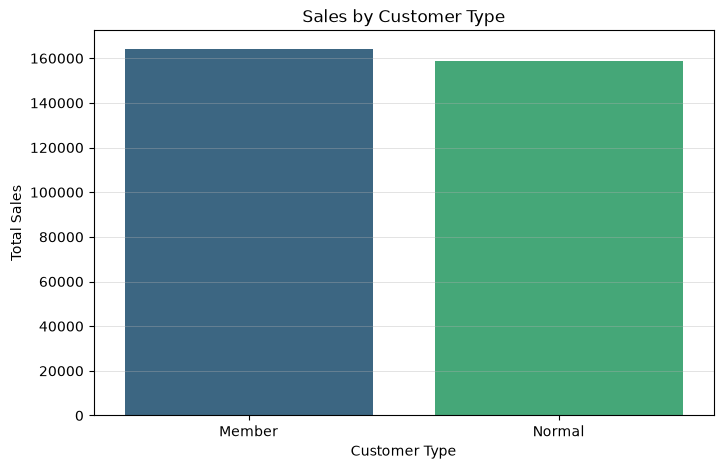

In [9]:
# 绘制客户类型销售对比图
plt.figure(figsize=(8, 5))
sns.barplot(x='Customer type', y='Total Sales', data=customer_type_analysis, palette='viridis')
plt.title('Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')
plt.grid(axis='y')  # 添加y轴网格
plt.show()

In [10]:
# 3. 产品线表现分析
# 统计各产品线的销售额和销售量
product_line_analysis = supermarket_data.groupby('Product line').agg({
    'Quantity': 'sum',  # 统计销售量
    'Total': 'sum'  # 统计销售额
}).rename(columns={'Quantity': 'Total Quantity', 'Total': 'Total Sales'}).reset_index()

C:\Users\xingh\AppData\Local\Temp\ipykernel_14080\4235985094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product line', y='Total Sales', data=product_line_analysis, palette='rocket')


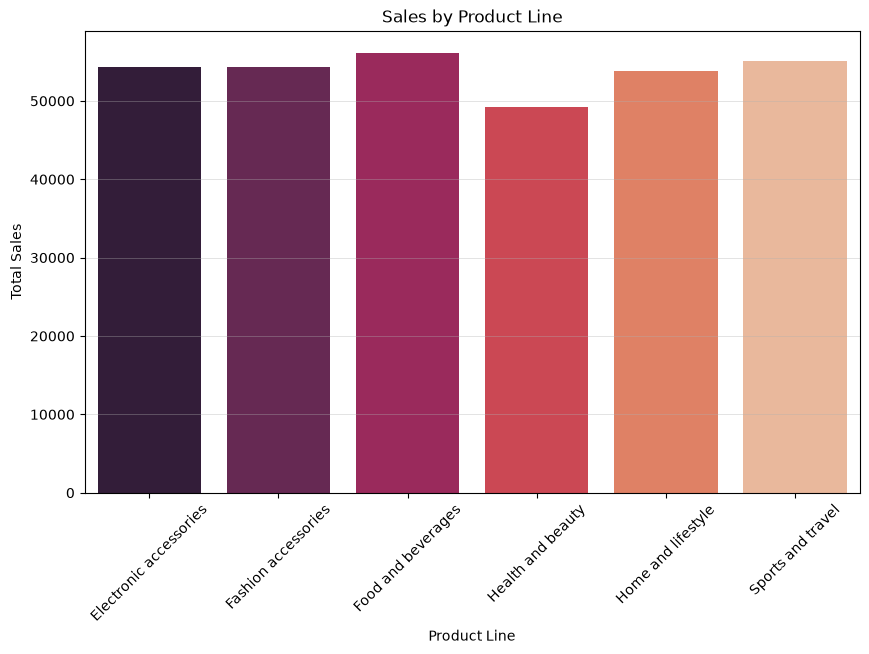

In [11]:
# 绘制产品线销售分析图
plt.figure(figsize=(10, 6))
sns.barplot(x='Product line', y='Total Sales', data=product_line_analysis, palette='rocket')
plt.title('Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)  # 旋转x轴刻度标签
plt.grid(axis='y')
plt.show()

In [12]:
# 4. 支付方式偏好分析
# 统计不同支付方式的使用次数和金额
payment_analysis = supermarket_data.groupby('Payment').agg({
    'Invoice ID': 'count',  # 统计交易次数
    'Total': 'sum'  # 统计交易金额
}).rename(columns={'Invoice ID': 'Transaction Count', 'Total': 'Total Amount'}).reset_index()

C:\Users\xingh\AppData\Local\Temp\ipykernel_14080\1344490472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Payment', y='Total Amount', data=payment_analysis, palette='pastel')


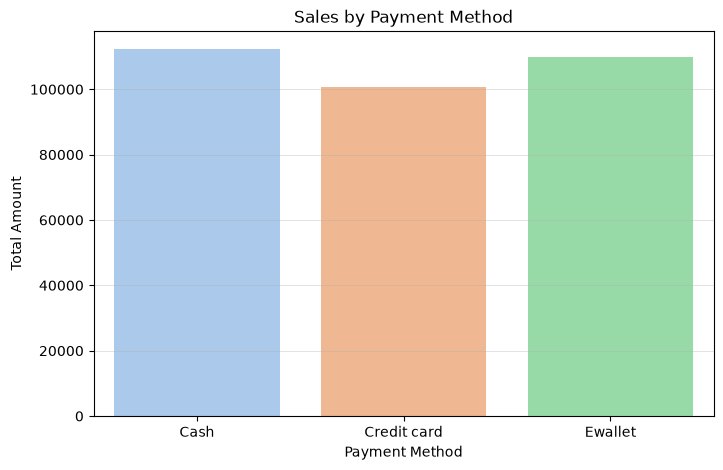

In [13]:
# 绘制支付方式分析图
plt.figure(figsize=(8, 5))
sns.barplot(x='Payment', y='Total Amount', data=payment_analysis, palette='pastel')
plt.title('Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Amount')
plt.grid(axis='y')
plt.show()

In [14]:
# 5. 分店销售分析
# 统计各分店的销售额
branch_sales = supermarket_data.groupby('Branch')['Total'].sum().reset_index()

C:\Users\xingh\AppData\Local\Temp\ipykernel_14080\3893025687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Branch', y='Total', data=branch_sales, palette='Set2')


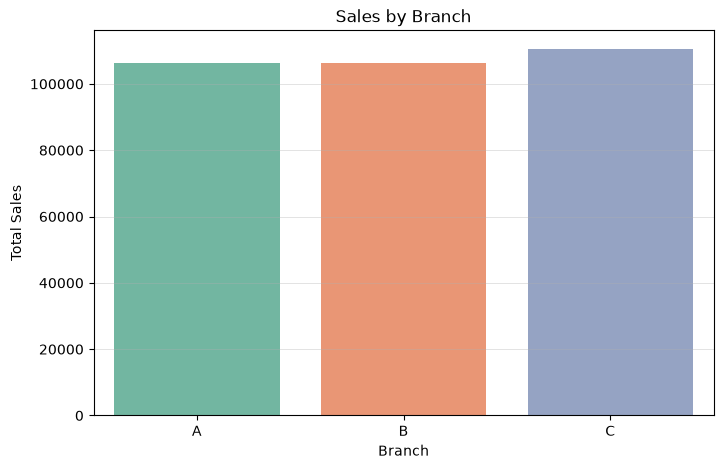

In [15]:
# 绘制分店销售分析图
plt.figure(figsize=(8, 5))
sns.barplot(x='Branch', y='Total', data=branch_sales, palette='Set2')
plt.title('Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.grid(axis='y')
plt.show()


In [16]:
# 6. 城市销售分析
# 统计各城市的销售额
city_sales = supermarket_data.groupby('City')['Total'].sum().reset_index()

C:\Users\xingh\AppData\Local\Temp\ipykernel_14080\2232272588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Total', data=city_sales, palette='Set1')


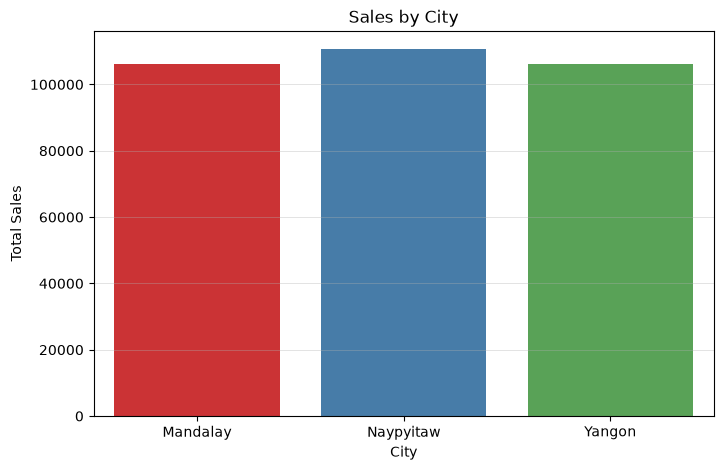

In [17]:
# 绘制城市销售分析图
plt.figure(figsize=(8, 5))
sns.barplot(x='City', y='Total', data=city_sales, palette='Set1')
plt.title('Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.grid(axis='y')
plt.show()

In [19]:
# 7. 销售时间分析
# 提取小时信息
supermarket_data['Hour'] = pd.to_datetime(supermarket_data['Time']).dt.hour

# 按小时统计销售额
hourly_sales = supermarket_data.groupby('Hour')['Total'].sum().reset_index()

C:\Users\xingh\AppData\Local\Temp\ipykernel_14080\3994571505.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  supermarket_data['Hour'] = pd.to_datetime(supermarket_data['Time']).dt.hour


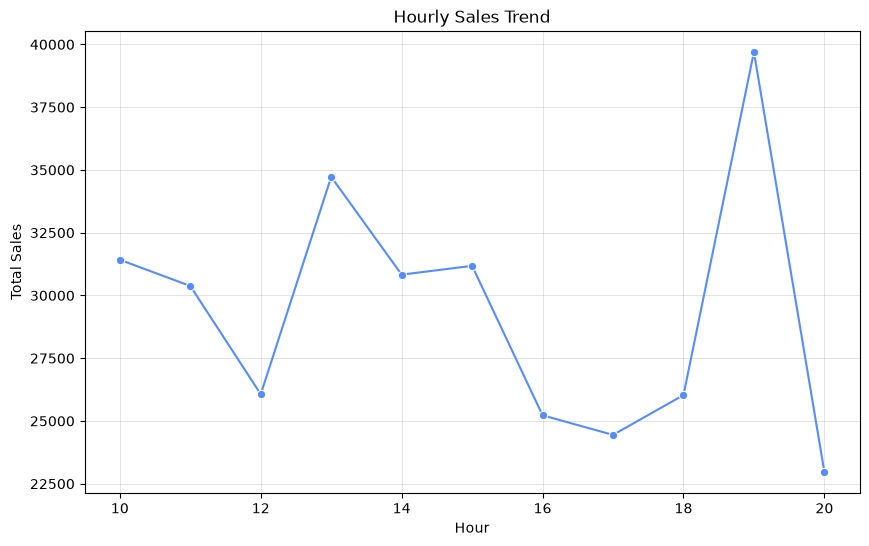

In [20]:
# 绘制每小时销售趋势图
plt.figure(figsize=(10, 6))
sns.lineplot(x='Hour', y='Total', data=hourly_sales, marker='o')
plt.title('Hourly Sales Trend')
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [21]:
# 时间序列模型：ARIMA模型预测
# 将数据按日期排序并设置日期为索引
daily_sales = daily_sales.sort_values('Date')
daily_sales.set_index('Date', inplace=True)

In [23]:
# 拟合ARIMA模型
warnings.filterwarnings("ignore")  # 忽略收敛警告
arima_model = ARIMA(daily_sales['Total'], order=(5, 1, 0))  # 这里的order参数需要根据数据进行调整
arima_result = arima_model.fit()

In [24]:
# 预测未来5天的销售额
forecast = arima_result.forecast(steps=5)
print("\nARIMA模型预测未来5天的销售额:")
print(forecast)


ARIMA模型预测未来5天的销售额:
2019-03-31    2700.616941
2019-04-01    2971.021459
2019-04-02    3338.935762
2019-04-03    3575.108955
2019-04-04    3485.929496
Freq: D, Name: predicted_mean, dtype: float64


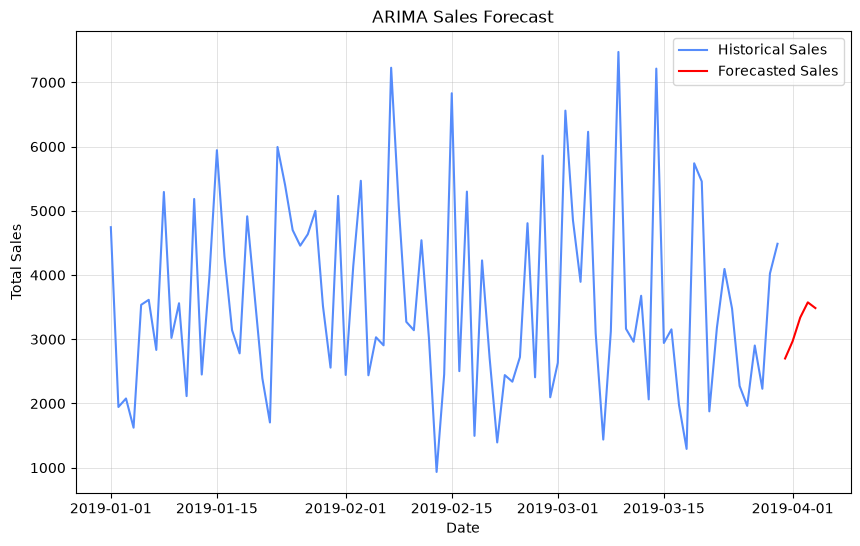

In [25]:
# 绘制ARIMA模型预测结果
plt.figure(figsize=(10, 6))
plt.plot(daily_sales['Total'], label='Historical Sales')  # 绘制历史销售数据
plt.plot(pd.date_range(start=daily_sales.index[-1], periods=6, freq='D')[1:], forecast, label='Forecasted Sales', color='red')  # 绘制预测数据
plt.title('ARIMA Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()